# NYISO Solar Forecasting: Technical Exploration for Residual Learning with ERA5 Weather Features

## Purpose

## Research Context

## Questions to Consider

## Imports and Configurations

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from solar_forecast.config import (
    MERGED_OUT,
    TS_COL   as ts_col,
    ZONE_COL as zone_col,
)

from solar_forecast.plots import (
    plot_capacity_by_zone,
    plot_zone_summary,
    plot_corr_heatmap,
)

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

2026-03-28 16:18:40.084 | INFO     | solar_forecast.config:<module>:14 - PROJ_ROOT path is: /Users/Sumaitat/Documents/Coding/ML_NYISOSolarForecast


## Load Merged Dataset and Schema Standardization

In [2]:
df = pd.read_csv(MERGED_OUT, low_memory=False)

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df["time_stamp"] = pd.to_datetime(df["time_stamp"], utc=True, errors="coerce")

numeric_cols = [
    "actual_mw",
    "forecast_mw",
    "capacity_mw",
    "temperature_2m",
    "surface_pressure",
    "cloud_cover",
    "windspeed_10m",
    "shortwave_radiation",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["zone_name"] = df["zone_name"].astype(str).str.strip().str.upper()

## Time Features and Target Construction

In [4]:
df["time_local"] = df["time_stamp"].dt.tz_convert("America/New_York")
df["date_local"] = df["time_local"].dt.date
df["year_from_ts"] = df["time_local"].dt.year

df["month_local"] = df["time_local"].dt.month
df["dayofweek_local"] = df["time_local"].dt.dayofweek
df["hour_local"] = df["time_local"].dt.hour
df["is_weekend"] = df["dayofweek_local"].isin([5, 6]).astype(int)
df["is_daylight_proxy"] = (df["shortwave_radiation"] > 0).astype(int)

In [5]:
df["forecast_error_mw"] = df["actual_mw"] - df["forecast_mw"]
df["absolute_error_mw"] = (df["actual_mw"] - df["forecast_mw"]).abs()
df["smape"] = np.where(
    (df["actual_mw"].abs() + df["forecast_mw"].abs()) > 0,
    200 * df["absolute_error_mw"] / (df["actual_mw"].abs() + df["forecast_mw"].abs()),
    np.nan
)

## Dataset Audit

In [6]:
df_system = df[df["zone_name"] == "SYSTEM"].copy()
df_zones = df[df["zone_name"] != "SYSTEM"].copy()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Time Range:", df["time_stamp"].min(), "to", df["time_stamp"].max())
print("Zones:", sorted(df["zone_name"].unique().tolist()))
print("System Row Only:", df_system.shape)
print("Zone Row Only:", df_zones.shape)

Shape: (509460, 23)
Columns: ['time_stamp', 'zone_name', 'actual_mw', 'forecast_mw', 'capacity_mw', 'time', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'year', 'time_local', 'date_local', 'year_from_ts', 'month_local', 'dayofweek_local', 'hour_local', 'is_weekend', 'is_daylight_proxy', 'forecast_error_mw', 'absolute_error_mw', 'smape']
Time Range: 2020-11-17 05:00:00+00:00 to 2025-09-21 03:00:00+00:00
Zones: ['CAPITL', 'CENTRL', 'DUNWOD', 'GENESE', 'HUD VL', 'LONGIL', 'MHK VL', 'MILLWD', 'N.Y.C.', 'NORTH', 'SYSTEM', 'WEST']
System Row Only: (42455, 23)
Zone Row Only: (467005, 23)


In [7]:
dataset_audit = pd.DataFrame(
    {
        "metric": [
            "row_count",
            "column_count",
            "unique_zones",
            "system_rows",
            "zone_rows",
        ],
        "value": [
            len(df),
            df.shape[1],
            df["zone_name"].nunique(),
            len(df_system),
            len(df_zones),
        ],
    }
)

dataset_audit

,metric,value
0,row_count,509460
1,column_count,23
2,unique_zones,12
3,system_rows,42455
4,zone_rows,467005


## Missingness and Coverage Check

In [8]:
missing_summary = (
    pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "missing_count": [df[c].isna().sum() for c in df.columns],
    })
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values(["missing_count", "column"], ascending=[False, True])
)

missing_summary

,column,dtype,missing_count,missing_pct
4,capacity_mw,float64,286836,56.301967
22,smape,float64,233555,45.843638
21,absolute_error_mw,float64,12000,2.355435
20,forecast_error_mw,float64,12000,2.355435
2,actual_mw,float64,8544,1.677070
3,forecast_mw,float64,3456,0.678365
8,cloud_cover,int64,0,0.000000
13,date_local,object,0,0.000000
16,dayofweek_local,int32,0,0.000000
17,hour_local,int32,0,0.000000


## Capacity Coverage

In [9]:
capacity_plot_df = (
    df.groupby("zone_name", as_index=False)
      .agg(
          capacity_nonmissing=("capacity_mw", lambda s: s.notna().sum()),
          capacity_missing_pct=("capacity_mw", lambda s: s.isna().mean() * 100),
          capacity_min=("capacity_mw", "min"),
          capacity_max=("capacity_mw", "max"),
      )
      .sort_values("capacity_max", ascending=False)
)

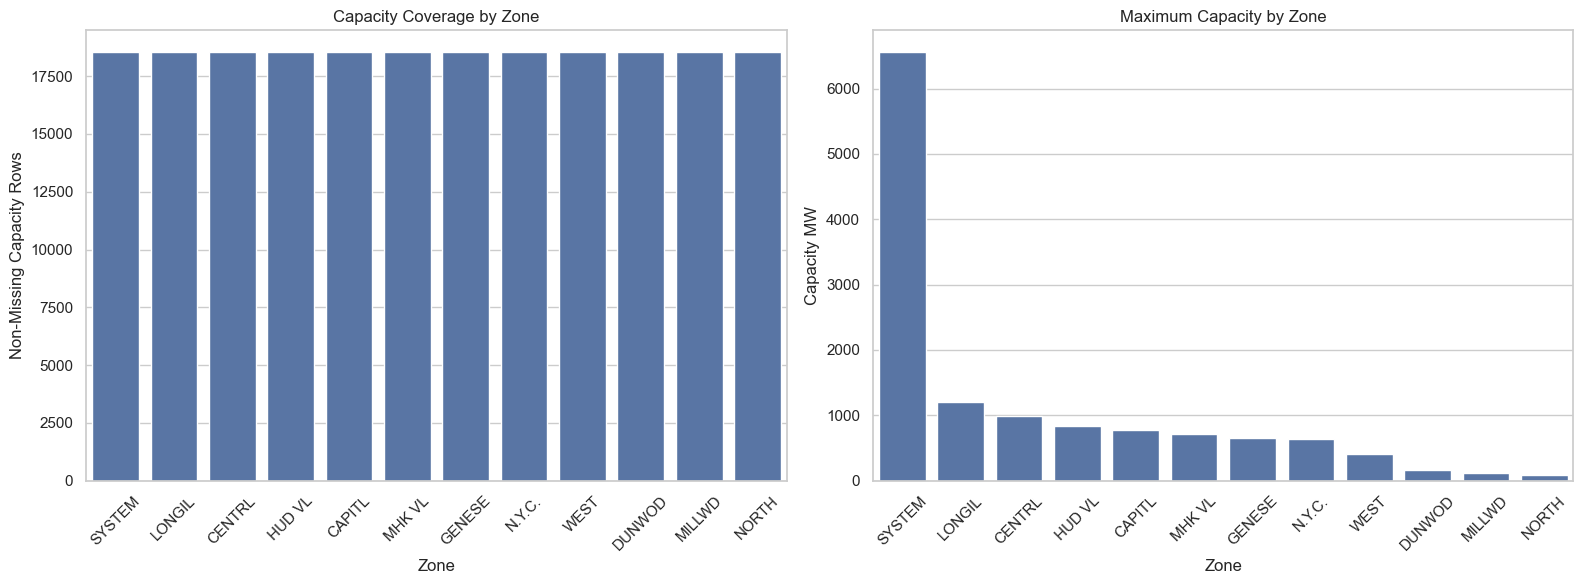

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=capacity_plot_df, x="zone_name", y="capacity_nonmissing", ax=axes[0])
axes[0].set_title("Capacity Coverage by Zone")
axes[0].set_xlabel("Zone")
axes[0].set_ylabel("Non-Missing Capacity Rows")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=capacity_plot_df, x="zone_name", y="capacity_max", ax=axes[1])
axes[1].set_title("Maximum Capacity by Zone")
axes[1].set_xlabel("Zone")
axes[1].set_ylabel("Capacity MW")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## System-Level Benchmark

In [11]:
system_error_summary = pd.DataFrame({
    "metric": ["ME", "MAE", "RMSE", "sMAPE", "Actual Mean", "Forecast Mean"],
    "value": [
        df_system["forecast_error_mw"].mean(),
        df_system["absolute_error_mw"].mean(),
        np.sqrt(np.nanmean(np.square(df_system["forecast_error_mw"]))),
        df_system["smape"].mean(),
        df_system["actual_mw"].mean(),
        df_system["forecast_mw"].mean(),
    ],
})

system_error_summary

,metric,value
0,ME,-2.175051
1,MAE,81.722045
2,RMSE,166.133840
3,sMAPE,32.200133
4,Actual Mean,583.512589
5,Forecast Mean,583.731486


## Zone Behavior Summary

In [12]:
zone_summary = (
    df_zones.groupby("zone_name", as_index=False)
      .agg(
          rows=("time_stamp", "size"),
          unique_hours=("time_stamp", "nunique"),
          actual_mean=("actual_mw", "mean"),
          actual_median=("actual_mw", "median"),
          actual_max=("actual_mw", "max"),
          forecast_mean=("forecast_mw", "mean"),
          forecast_median=("forecast_mw", "median"),
          forecast_max=("forecast_mw", "max"),
          mae=("absolute_error_mw", "mean"),
          rmse=("forecast_error_mw", lambda s: np.sqrt(np.nanmean(np.square(s)))),
          me=("forecast_error_mw", "mean"),
          smape_mean=("smape", "mean"),
          daylight_actual_mean=("actual_mw", lambda s: s[df_zones.loc[s.index, "is_daylight_proxy"] == 1].mean()),
          nighttime_actual_mean=("actual_mw", lambda s: s[df_zones.loc[s.index, "is_daylight_proxy"] == 0].mean()),
      )
      .sort_values("actual_mean", ascending=False)
)

zone_summary

,zone_name,rows,unique_hours,actual_mean,actual_median,actual_max,forecast_mean,forecast_median,forecast_max,mae,rmse,me,smape_mean,daylight_actual_mean,nighttime_actual_mean
5,LONGIL,42455,42455,114.260794,2.99,821.67,115.790265,6.27,841.17,23.189507,47.848841,-1.938118,40.942147,210.714002,2.024517
1,CENTRL,42455,42455,79.074250,1.80,854.18,78.159695,2.44,867.10,17.068300,37.753586,0.650671,42.290204,146.356513,0.782289
0,CAPITL,42455,42455,76.956329,2.14,646.75,76.516414,3.76,643.89,16.330465,33.698112,0.190426,42.009168,142.151084,1.093465
4,HUD VL,42455,42455,76.705682,2.20,662.28,78.053159,3.89,664.46,14.667900,30.961976,-1.646729,38.708236,141.514273,1.292171
6,MHK VL,42455,42455,61.779922,1.82,605.78,59.815934,2.27,612.09,12.341302,25.653284,1.805735,39.427570,114.177197,0.808646
8,N.Y.C.,42455,42455,53.703594,1.49,423.74,54.659159,2.76,441.56,10.452867,21.993193,-1.167053,38.979720,99.203790,0.757997
3,GENESE,42455,42455,48.828916,0.96,578.23,48.966156,1.53,565.59,10.418230,23.399811,-0.292798,42.590873,90.448907,0.398459
10,WEST,42455,42455,41.986886,0.97,350.71,41.349809,1.36,374.44,9.085207,19.398153,0.522186,42.462712,77.840314,0.266601
2,DUNWOD,42455,42455,13.641792,0.43,116.99,13.744605,0.73,120.09,2.730844,5.909491,-0.146106,39.366078,25.146082,0.255004
7,MILLWD,42455,42455,9.809044,0.31,94.33,9.958804,0.51,95.77,1.887440,4.065609,-0.184890,38.472361,18.088792,0.174443


## System versus Sum of All Zones 

In [13]:
system_vs_zones = (
    df_system[["time_stamp", "actual_mw", "forecast_mw"]]
    .rename(columns={"actual_mw": "system_actual_mw", "forecast_mw": "system_forecast_mw"})
    .merge(
        df_zones.groupby("time_stamp", as_index=False).agg(
            zone_actual_sum=("actual_mw", "sum"),
            zone_forecast_sum=("forecast_mw", "sum"),
            zone_count=("zone_name", "nunique"),
        ),
        on="time_stamp",
        how="left"
    )
)

system_vs_zones["actual_diff_system_minus_zone_sum"] = (
    system_vs_zones["system_actual_mw"] - system_vs_zones["zone_actual_sum"]
)
system_vs_zones["forecast_diff_system_minus_zone_sum"] = (
    system_vs_zones["system_forecast_mw"] - system_vs_zones["zone_forecast_sum"]
)

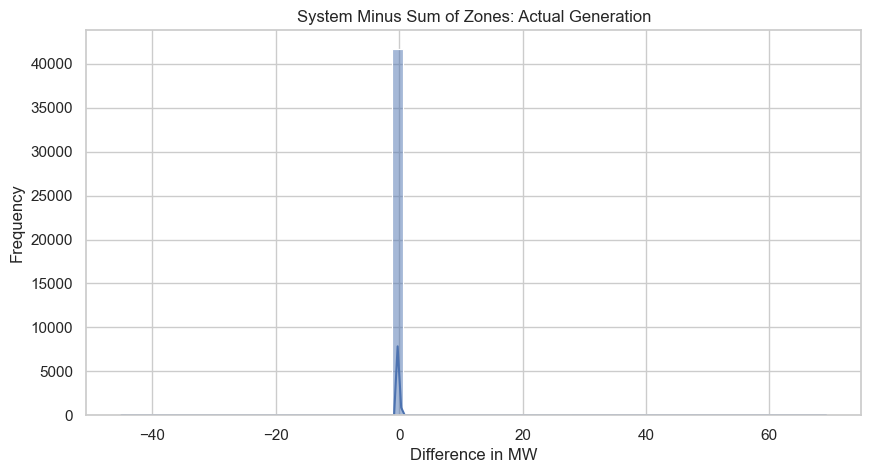

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(
    system_vs_zones["actual_diff_system_minus_zone_sum"].dropna(), 
    bins=60,
    kde=True,
)
plt.title("System Minus Sum of Zones: Actual Generation")
plt.xlabel("Difference in MW")
plt.ylabel("Frequency")
plt.show()

## System-Level Temporal Structure

In [15]:
system_hourly = (
    df_system.groupby("hour_local", as_index=False)
      .agg(
          actual_mean=("actual_mw", "mean"),
          forecast_mean=("forecast_mw", "mean"),
          residual_mean=("forecast_error_mw", "mean"),
          mae=("absolute_error_mw", "mean"),
          shortwave_mean=("shortwave_radiation", "mean"),
          cloud_mean=("cloud_cover", "mean"),
          temp_mean=("temperature_2m", "mean"),
      )
      .sort_values("hour_local")
)

system_monthly = (
    df_system.groupby("month_local", as_index=False)
      .agg(
          actual_mean=("actual_mw", "mean"),
          forecast_mean=("forecast_mw", "mean"),
          residual_mean=("forecast_error_mw", "mean"),
          mae=("absolute_error_mw", "mean"),
          shortwave_mean=("shortwave_radiation", "mean"),
          cloud_mean=("cloud_cover", "mean"),
          temp_mean=("temperature_2m", "mean"),
      )
      .sort_values("month_local")
)

system_daily = (
    df_system.groupby("date_local", as_index=False)
      .agg(
          actual_sum=("actual_mw", "sum"),
          forecast_sum=("forecast_mw", "sum"),
          residual_mean=("forecast_error_mw", "mean"),
          mae=("absolute_error_mw", "mean"),
          shortwave_sum=("shortwave_radiation", "sum"),
          cloud_mean=("cloud_cover", "mean"),
          temp_mean=("temperature_2m", "mean"),
      )
      .sort_values("date_local")
)

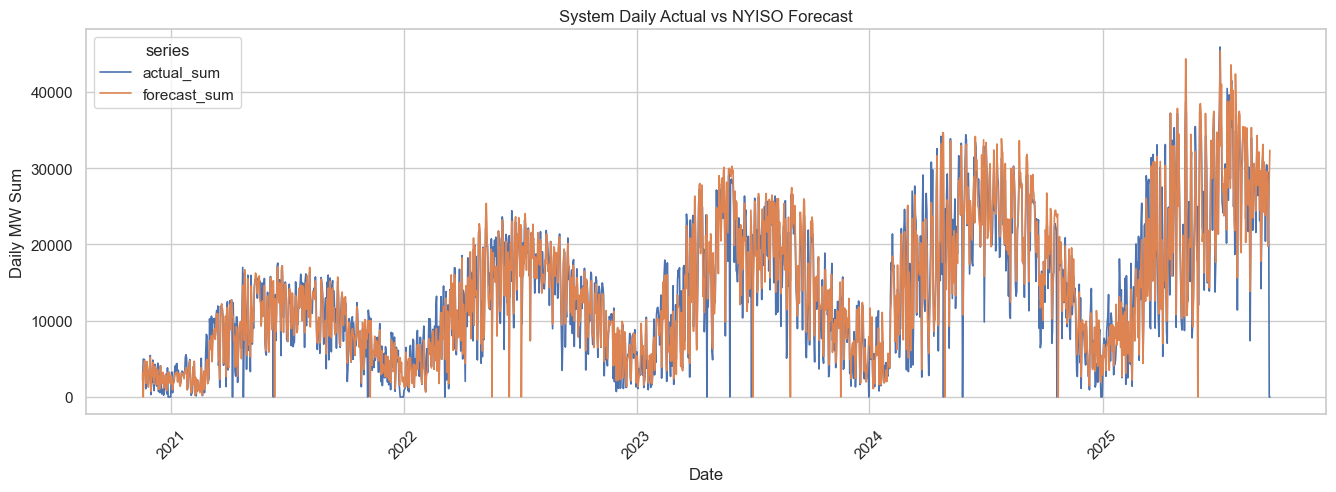

In [16]:
system_daily_melt = system_daily.melt(
    id_vars="date_local",
    value_vars=["actual_sum", "forecast_sum"],
    var_name="series",
    value_name="mw",
)

plt.figure(figsize=(16, 5))
sns.lineplot(data=system_daily_melt, x="date_local", y="mw", hue="series", linewidth=1.2)
plt.title("System Daily Actual vs NYISO Forecast")
plt.xlabel("Date")
plt.ylabel("Daily MW Sum")
plt.xticks(rotation=45)
plt.show()

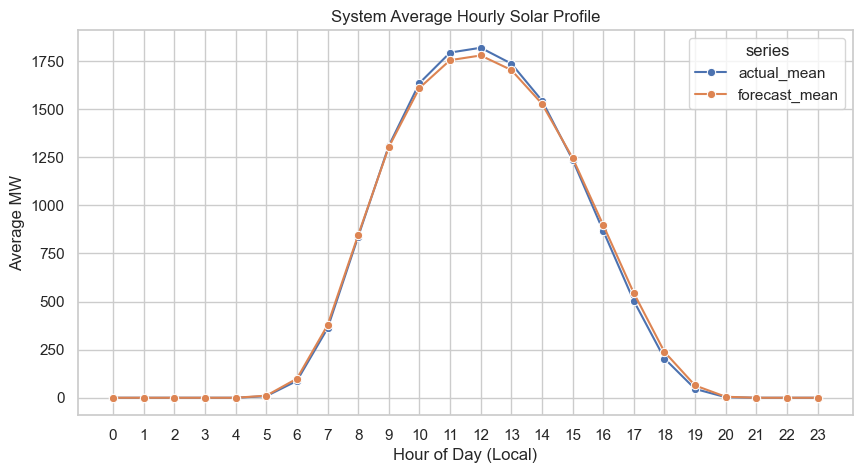

In [17]:
system_hourly_melt = system_hourly.melt(
    id_vars="hour_local",
    value_vars=["actual_mean", "forecast_mean"],
    var_name="series",
    value_name="mw",
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=system_hourly_melt, x="hour_local", y="mw", hue="series", marker="o")
plt.title("System Average Hourly Solar Profile")
plt.xlabel("Hour of Day (Local)")
plt.ylabel("Average MW")
plt.xticks(range(0, 24))
plt.show()

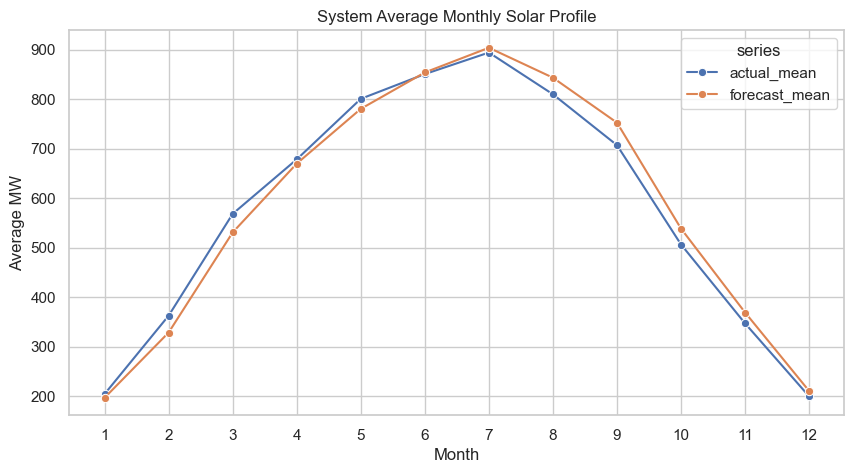

In [18]:
system_monthly_melt = system_monthly.melt(
    id_vars="month_local",
    value_vars=["actual_mean", "forecast_mean"],
    var_name="series",
    value_name="mw",
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=system_monthly_melt, x="month_local", y="mw", hue="series", marker="o")
plt.title("System Average Monthly Solar Profile")
plt.xlabel("Month")
plt.ylabel("Average MW")
plt.xticks(range(1, 13))
plt.show()

## Residual Diagnostics for the Benchmark Forecast

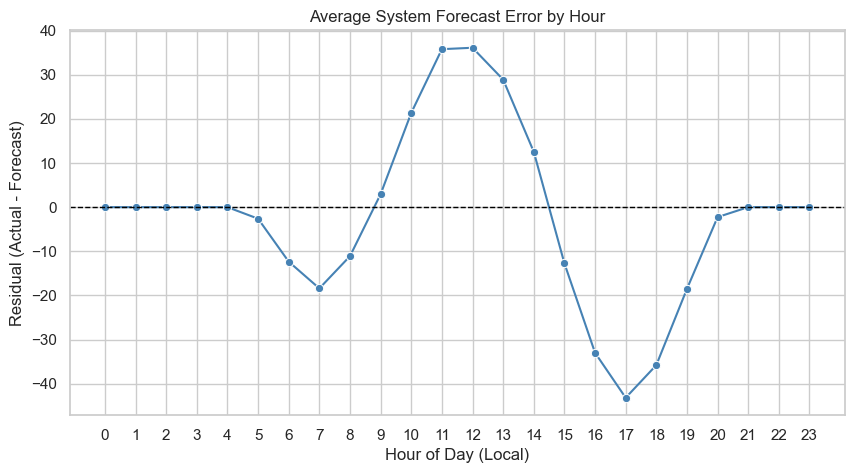

In [19]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=system_hourly, x="hour_local", y="residual_mean", marker="o", color="steelblue")
plt.axhline(0, linewidth=1, color="black", linestyle="--")
plt.title("Average System Forecast Error by Hour")
plt.xlabel("Hour of Day (Local)")
plt.ylabel("Residual (Actual - Forecast)")
plt.xticks(range(0, 24))
plt.show()

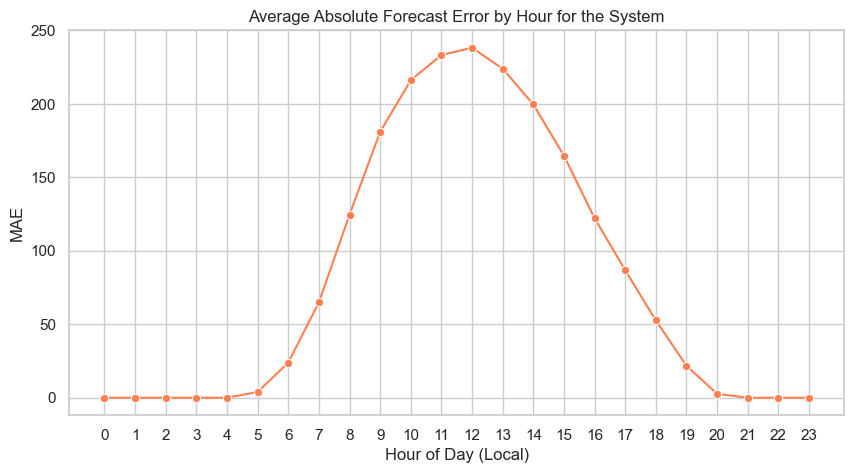

In [20]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=system_hourly, x="hour_local", y="mae", marker="o", color="coral")
plt.title("Average Absolute Forecast Error by Hour for the System")
plt.xlabel("Hour of Day (Local)")
plt.ylabel("MAE")
plt.xticks(range(0, 24))
plt.show()

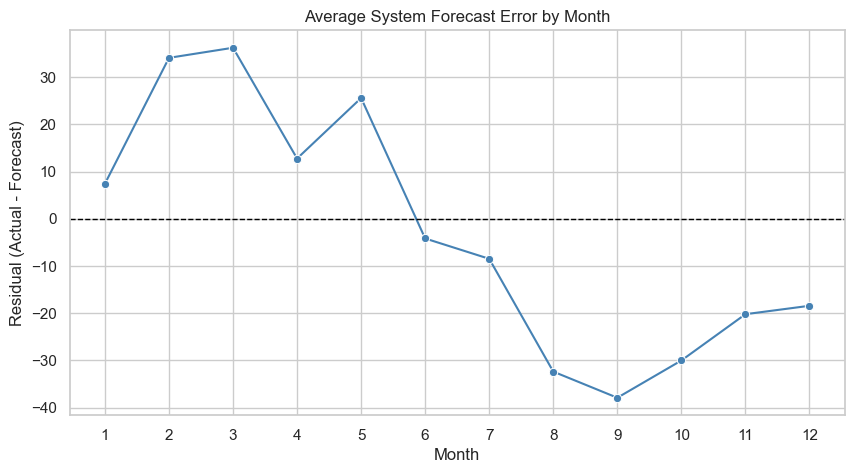

In [21]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=system_monthly, x="month_local", y="residual_mean", marker="o", color="steelblue")
plt.axhline(0, linewidth=1, color="black", linestyle="--")
plt.title("Average System Forecast Error by Month")
plt.xlabel("Month")
plt.ylabel("Residual (Actual - Forecast)")
plt.xticks(range(1, 13))
plt.show()

## Forecast Accuracy and Actual Generation Across Zones

In [22]:
zone_scatter        = df_zones[["zone_name", "forecast_mw", "actual_mw"]].dropna().copy()
zone_scatter_counts = zone_scatter.groupby("zone_name").size()

zone_scatter_large = (
    zone_scatter.groupby("zone_name", group_keys=False)
    .filter(lambda x: len(x) >= 3000)
    .groupby("zone_name", group_keys=False)
    .sample(n=3000, random_state=42)
)

small_zones        = zone_scatter_counts[zone_scatter_counts < 3000].index.tolist()
zone_scatter_small = zone_scatter[zone_scatter["zone_name"].isin(small_zones)].copy()

zone_scatter_sample = pd.concat([zone_scatter_large, zone_scatter_small], ignore_index=True)

max_val = max(zone_scatter_sample["forecast_mw"].max(), zone_scatter_sample["actual_mw"].max())

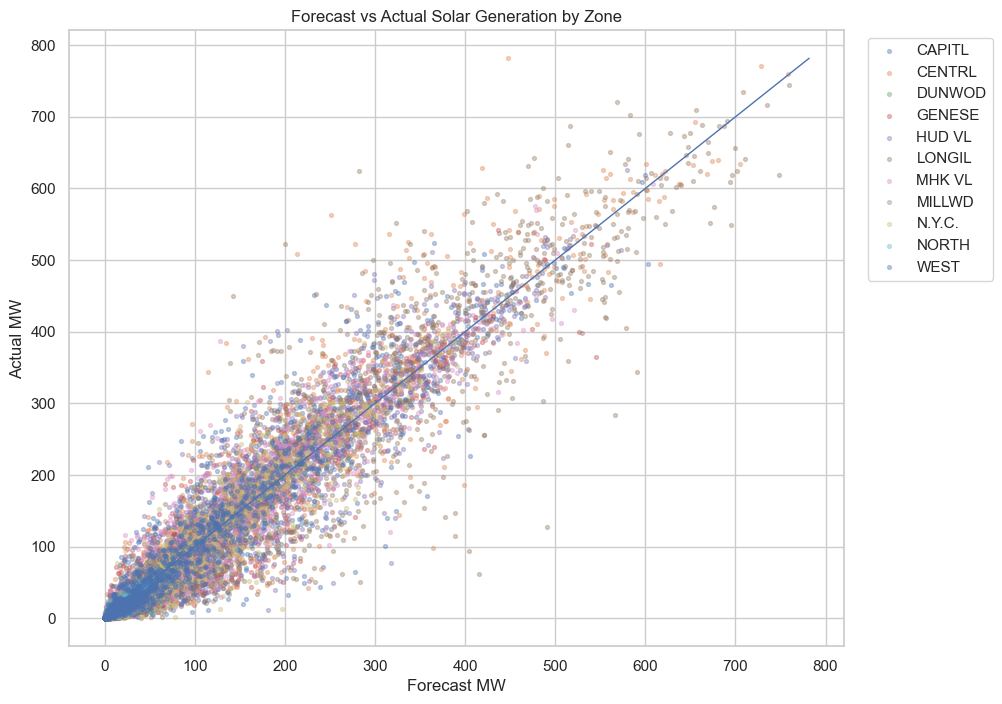

In [23]:
plt.figure(figsize=(10, 8))

for zone in sorted(zone_scatter_sample["zone_name"].dropna().unique()):
    temp = zone_scatter_sample[zone_scatter_sample["zone_name"] == zone]
    plt.scatter(temp["forecast_mw"], temp["actual_mw"], s=8, alpha=0.35, label=zone)

plt.plot([0, max_val], [0, max_val], linewidth=1)

plt.title("Forecast vs Actual Solar Generation by Zone")
plt.xlabel("Forecast MW")
plt.ylabel("Actual MW")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

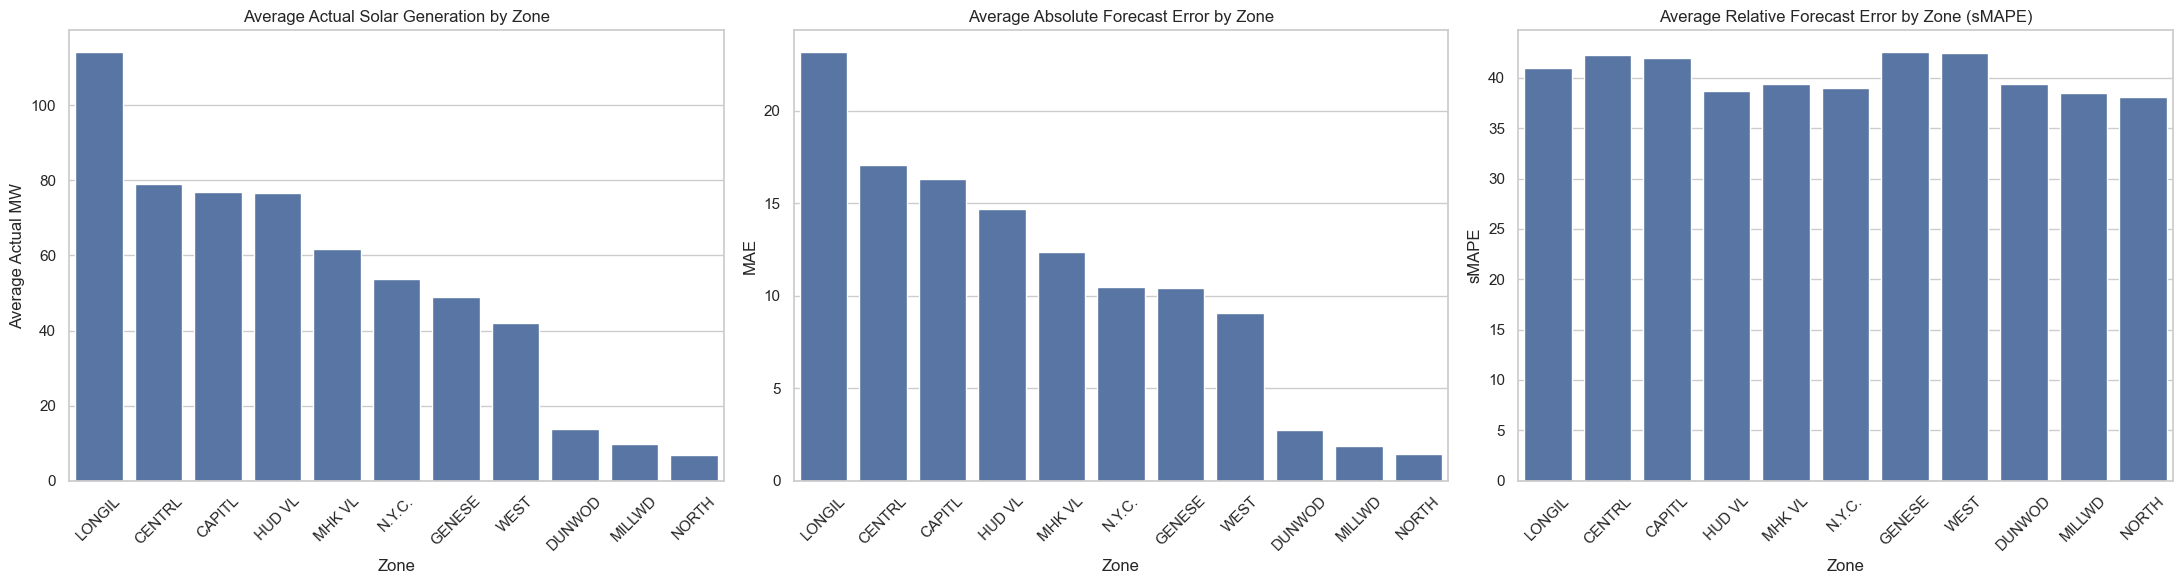

In [24]:
zone_error_plot = zone_summary.sort_values("mae", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=zone_summary, x="zone_name", y="actual_mean", ax=axes[0])
axes[0].set_title("Average Actual Solar Generation by Zone")
axes[0].set_xlabel("Zone")
axes[0].set_ylabel("Average Actual MW")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=zone_error_plot, x="zone_name", y="mae", ax=axes[1])
axes[1].set_title("Average Absolute Forecast Error by Zone")
axes[1].set_xlabel("Zone")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=zone_error_plot, x="zone_name", y="smape_mean", ax=axes[2])
axes[2].set_title("Average Relative Forecast Error by Zone (sMAPE)")
axes[2].set_xlabel("Zone")
axes[2].set_ylabel("sMAPE")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

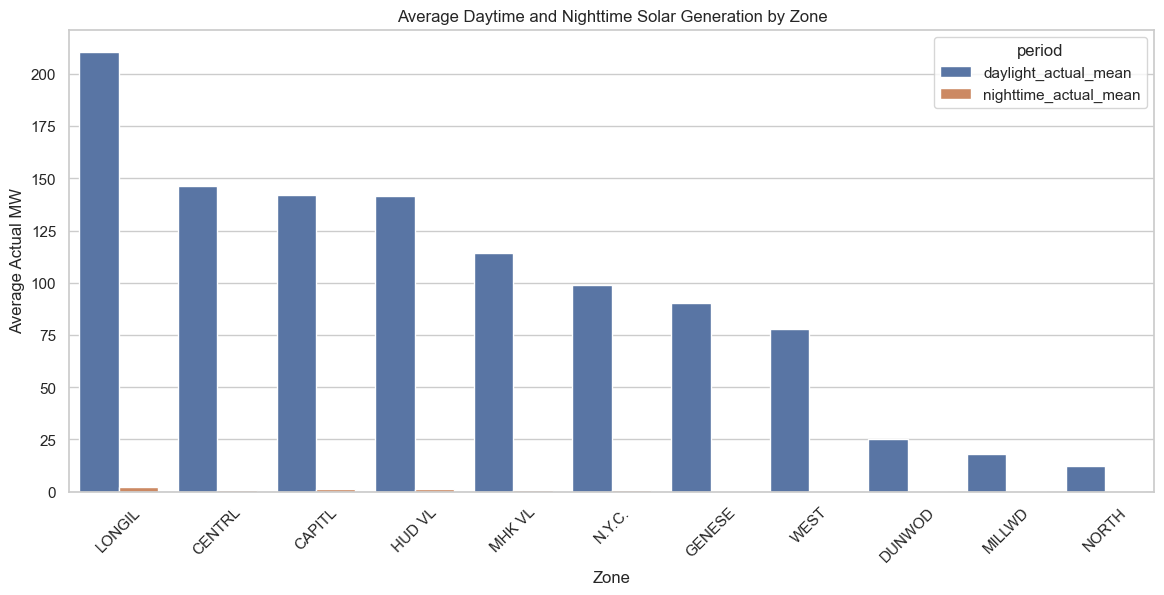

In [25]:
zone_day_night = zone_summary.sort_values("daylight_actual_mean", ascending=False)

zone_day_night_melt = zone_day_night.melt(
    id_vars="zone_name",
    value_vars=["daylight_actual_mean", "nighttime_actual_mean"],
    var_name="period",
    value_name="avg_mw",
)

plt.figure(figsize=(14, 6))
sns.barplot(data=zone_day_night_melt, x="zone_name", y="avg_mw", hue="period")
plt.title("Average Daytime and Nighttime Solar Generation by Zone")
plt.xlabel("Zone")
plt.ylabel("Average Actual MW")
plt.xticks(rotation=45)
plt.show()

## Zone Hourly Profiles

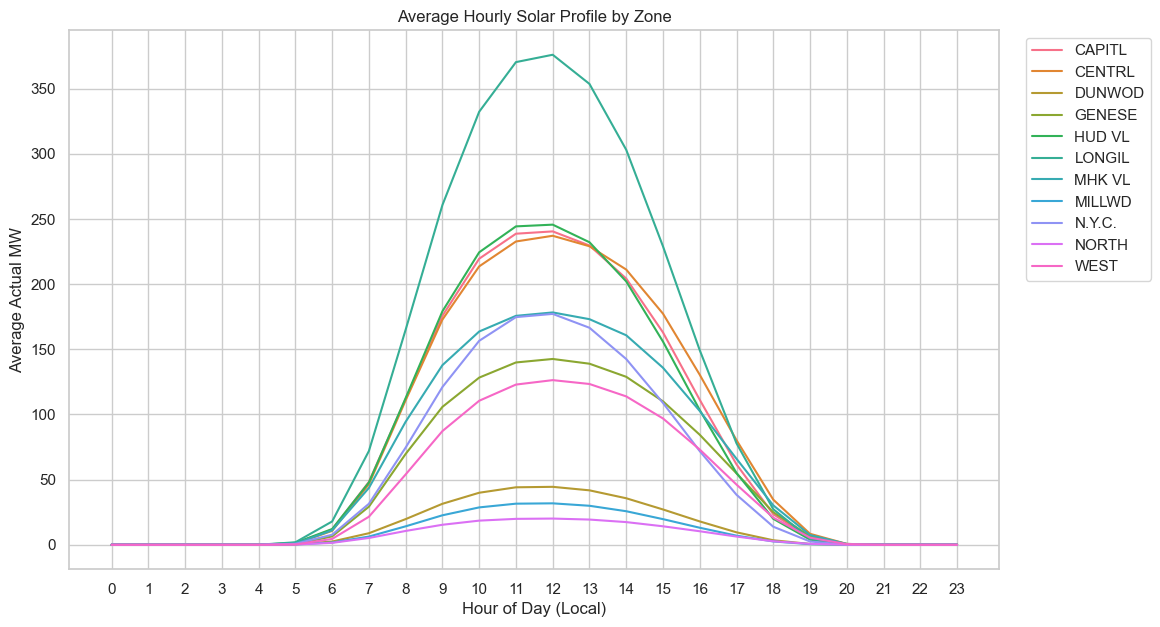

In [26]:
zone_hourly = (
    df_zones.groupby(["zone_name", "hour_local"], as_index=False)
      .agg(
          actual_mean=("actual_mw", "mean"),
          forecast_mean=("forecast_mw", "mean"),
      )
      .sort_values(["zone_name", "hour_local"])
)

plt.figure(figsize=(12, 7))

sns.lineplot(
    data=zone_hourly,
    x="hour_local",
    y="actual_mean",
    hue="zone_name",
    linewidth=1.5,
)

plt.title("Average Hourly Solar Profile by Zone")
plt.xlabel("Hour of Day (Local)")
plt.ylabel("Average Actual MW")
plt.xticks(range(0, 24))
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

## Meteorological Relationships With System Solar Output

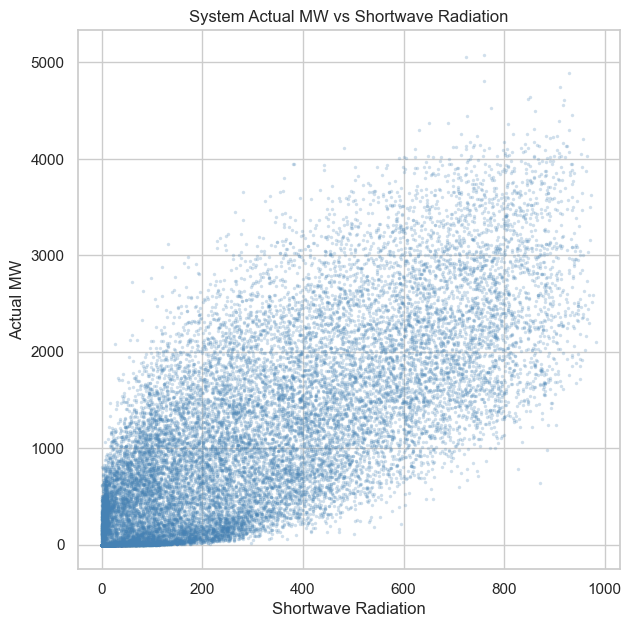

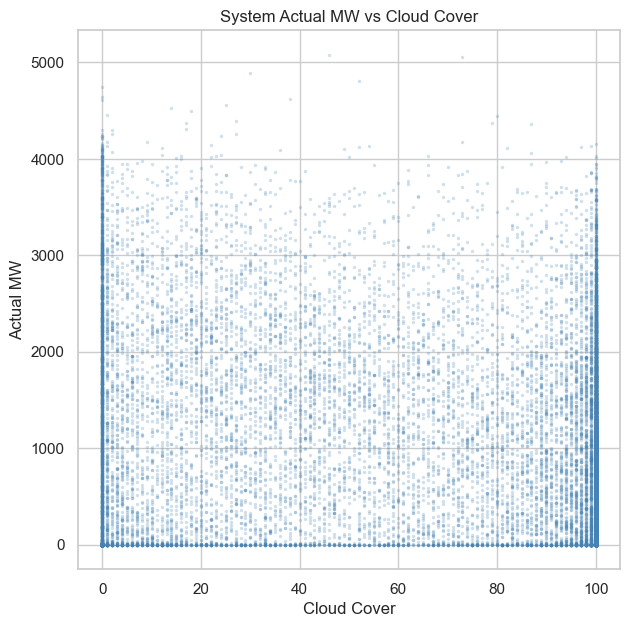

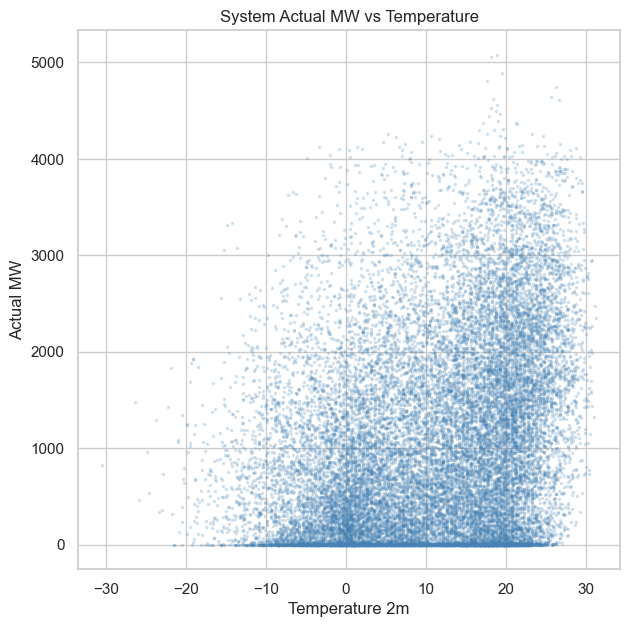

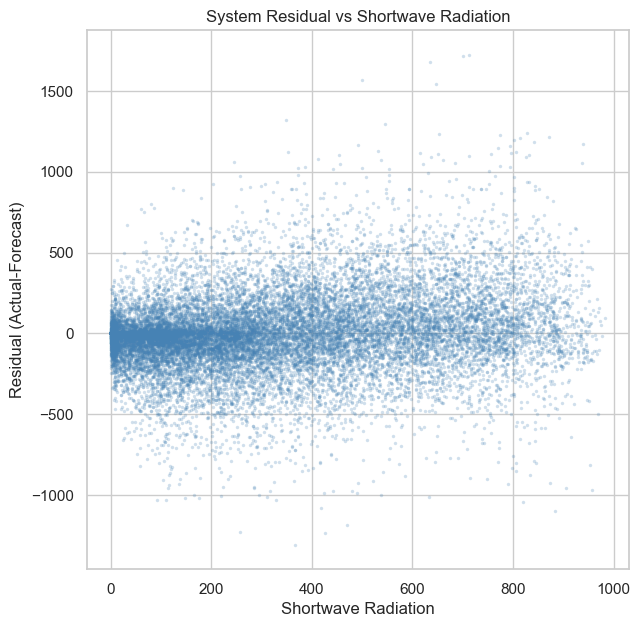

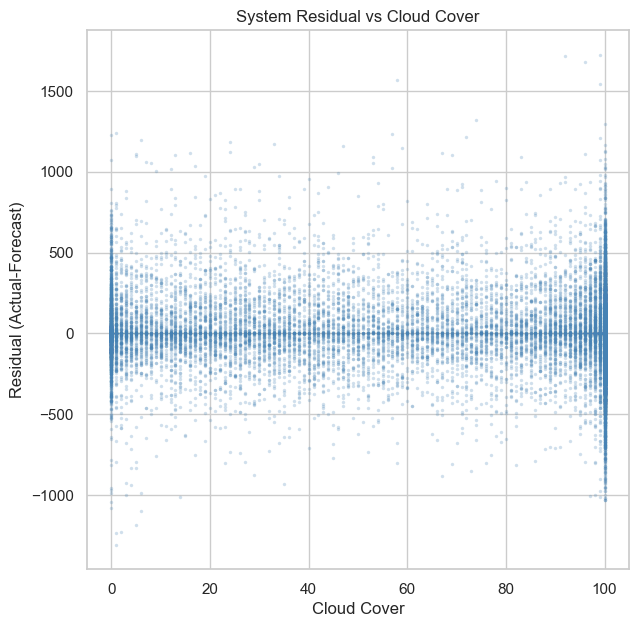

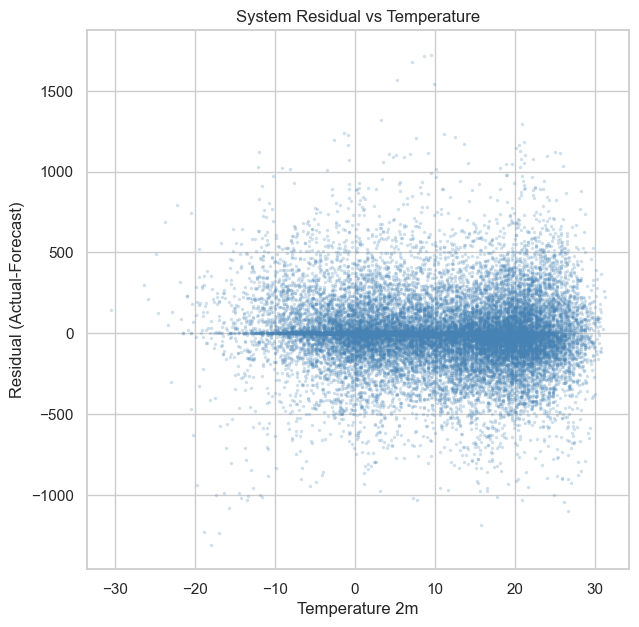

In [27]:
system_daylight = df_system[df_system["is_daylight_proxy"] == 1].copy()

weather_scatter_vars = [
    ("shortwave_radiation", "Shortwave Radiation", "actual_mw",        "Actual MW",                 "System Actual MW vs Shortwave Radiation"),
    ("cloud_cover",         "Cloud Cover",         "actual_mw",        "Actual MW",                 "System Actual MW vs Cloud Cover"),
    ("temperature_2m",      "Temperature 2m",      "actual_mw",        "Actual MW",                 "System Actual MW vs Temperature"),
    ("shortwave_radiation", "Shortwave Radiation", "forecast_error_mw", "Residual (Actual-Forecast)", "System Residual vs Shortwave Radiation"),
    ("cloud_cover",         "Cloud Cover",         "forecast_error_mw", "Residual (Actual-Forecast)", "System Residual vs Cloud Cover"),
    ("temperature_2m",      "Temperature 2m",      "forecast_error_mw", "Residual (Actual-Forecast)", "System Residual vs Temperature"),
]

for xcol, xlabel, ycol, ylabel, title in weather_scatter_vars:
    plt.figure(figsize=(7, 7))
    sns.scatterplot(
        data=system_daylight,
        x=xcol,
        y=ycol,
        s=6,
        alpha=0.25,
        linewidth=0,
        color="steelblue",
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

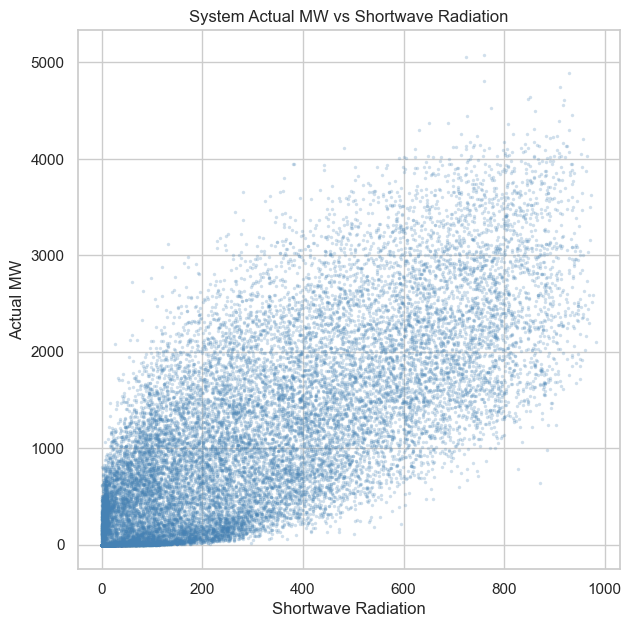

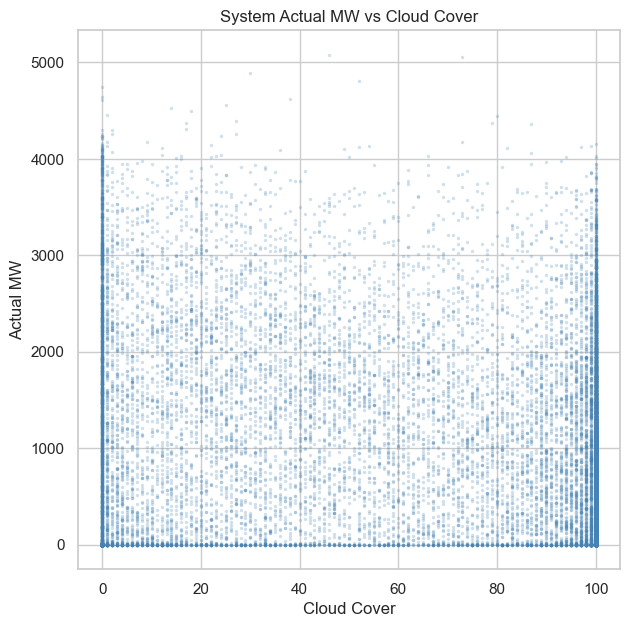

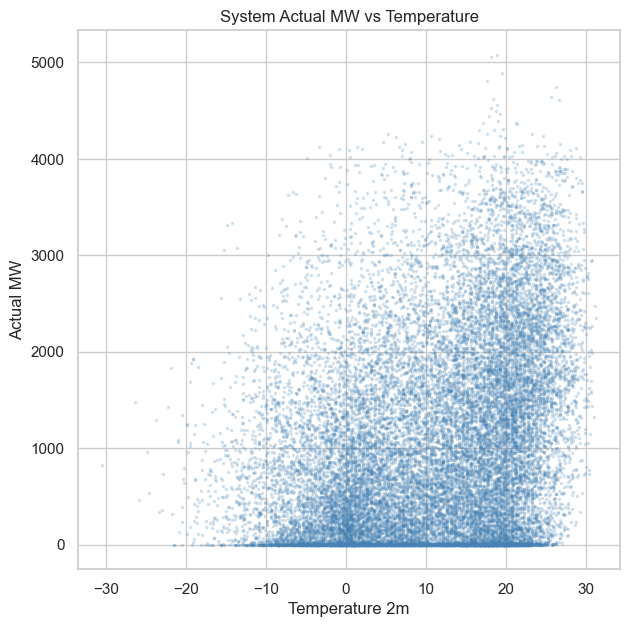

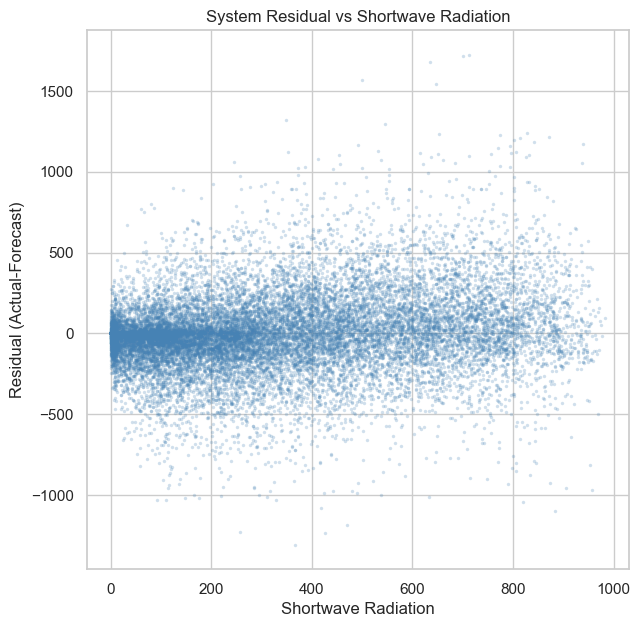

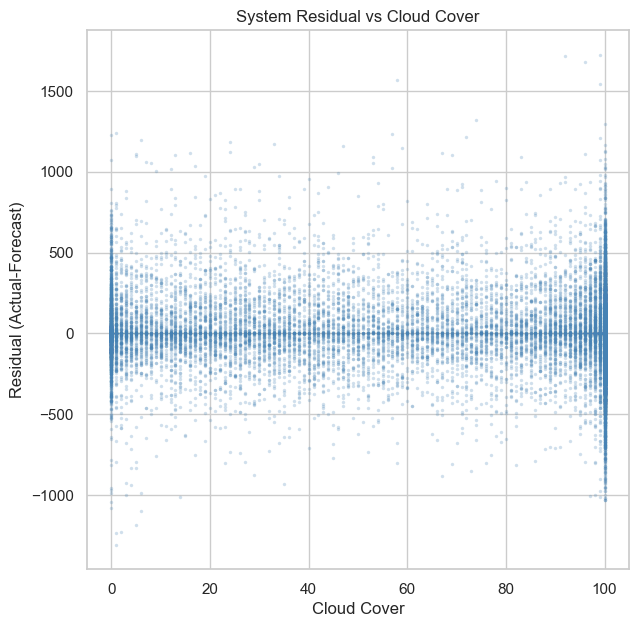

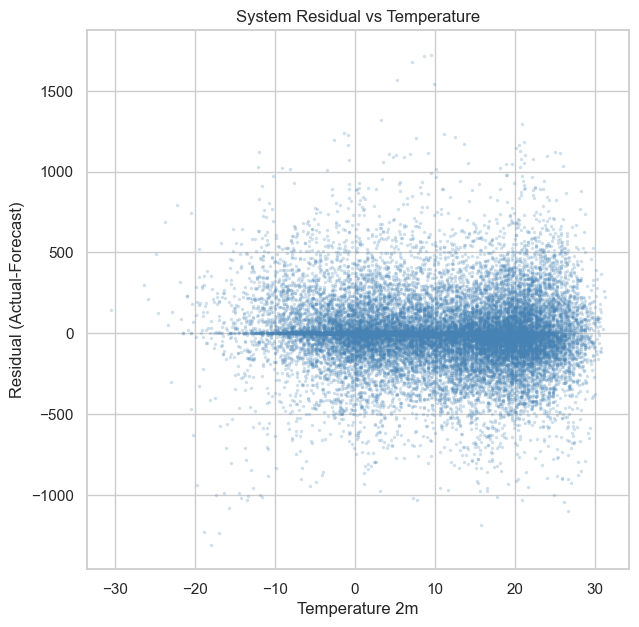

In [28]:
system_daylight = df_system[df_system["is_daylight_proxy"] == 1].copy()

weather_scatter_vars = [ 
    ("shortwave_radiation", "Shortwave Radiation", "actual_mw",        "Actual MW",                 "System Actual MW vs Shortwave Radiation"),
    ("cloud_cover",         "Cloud Cover",         "actual_mw",        "Actual MW",                 "System Actual MW vs Cloud Cover"),
    ("temperature_2m",      "Temperature 2m",      "actual_mw",        "Actual MW",                 "System Actual MW vs Temperature"),
    ("shortwave_radiation", "Shortwave Radiation", "forecast_error_mw", "Residual (Actual-Forecast)", "System Residual vs Shortwave Radiation"),
    ("cloud_cover",         "Cloud Cover",         "forecast_error_mw", "Residual (Actual-Forecast)", "System Residual vs Cloud Cover"),
    ("temperature_2m",      "Temperature 2m",      "forecast_error_mw", "Residual (Actual-Forecast)", "System Residual vs Temperature"),
]

for xcol, xlabel, ycol, ylabel, title in weather_scatter_vars:
    
    plt.figure(figsize=(7, 7))
    
    sns.scatterplot(
        data=system_daylight,
        x=xcol,
        y=ycol,
        s=6,
        alpha=0.25,
        linewidth=0,
        color="steelblue",
    )
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

## Multivariate Dependence and Feature Screening

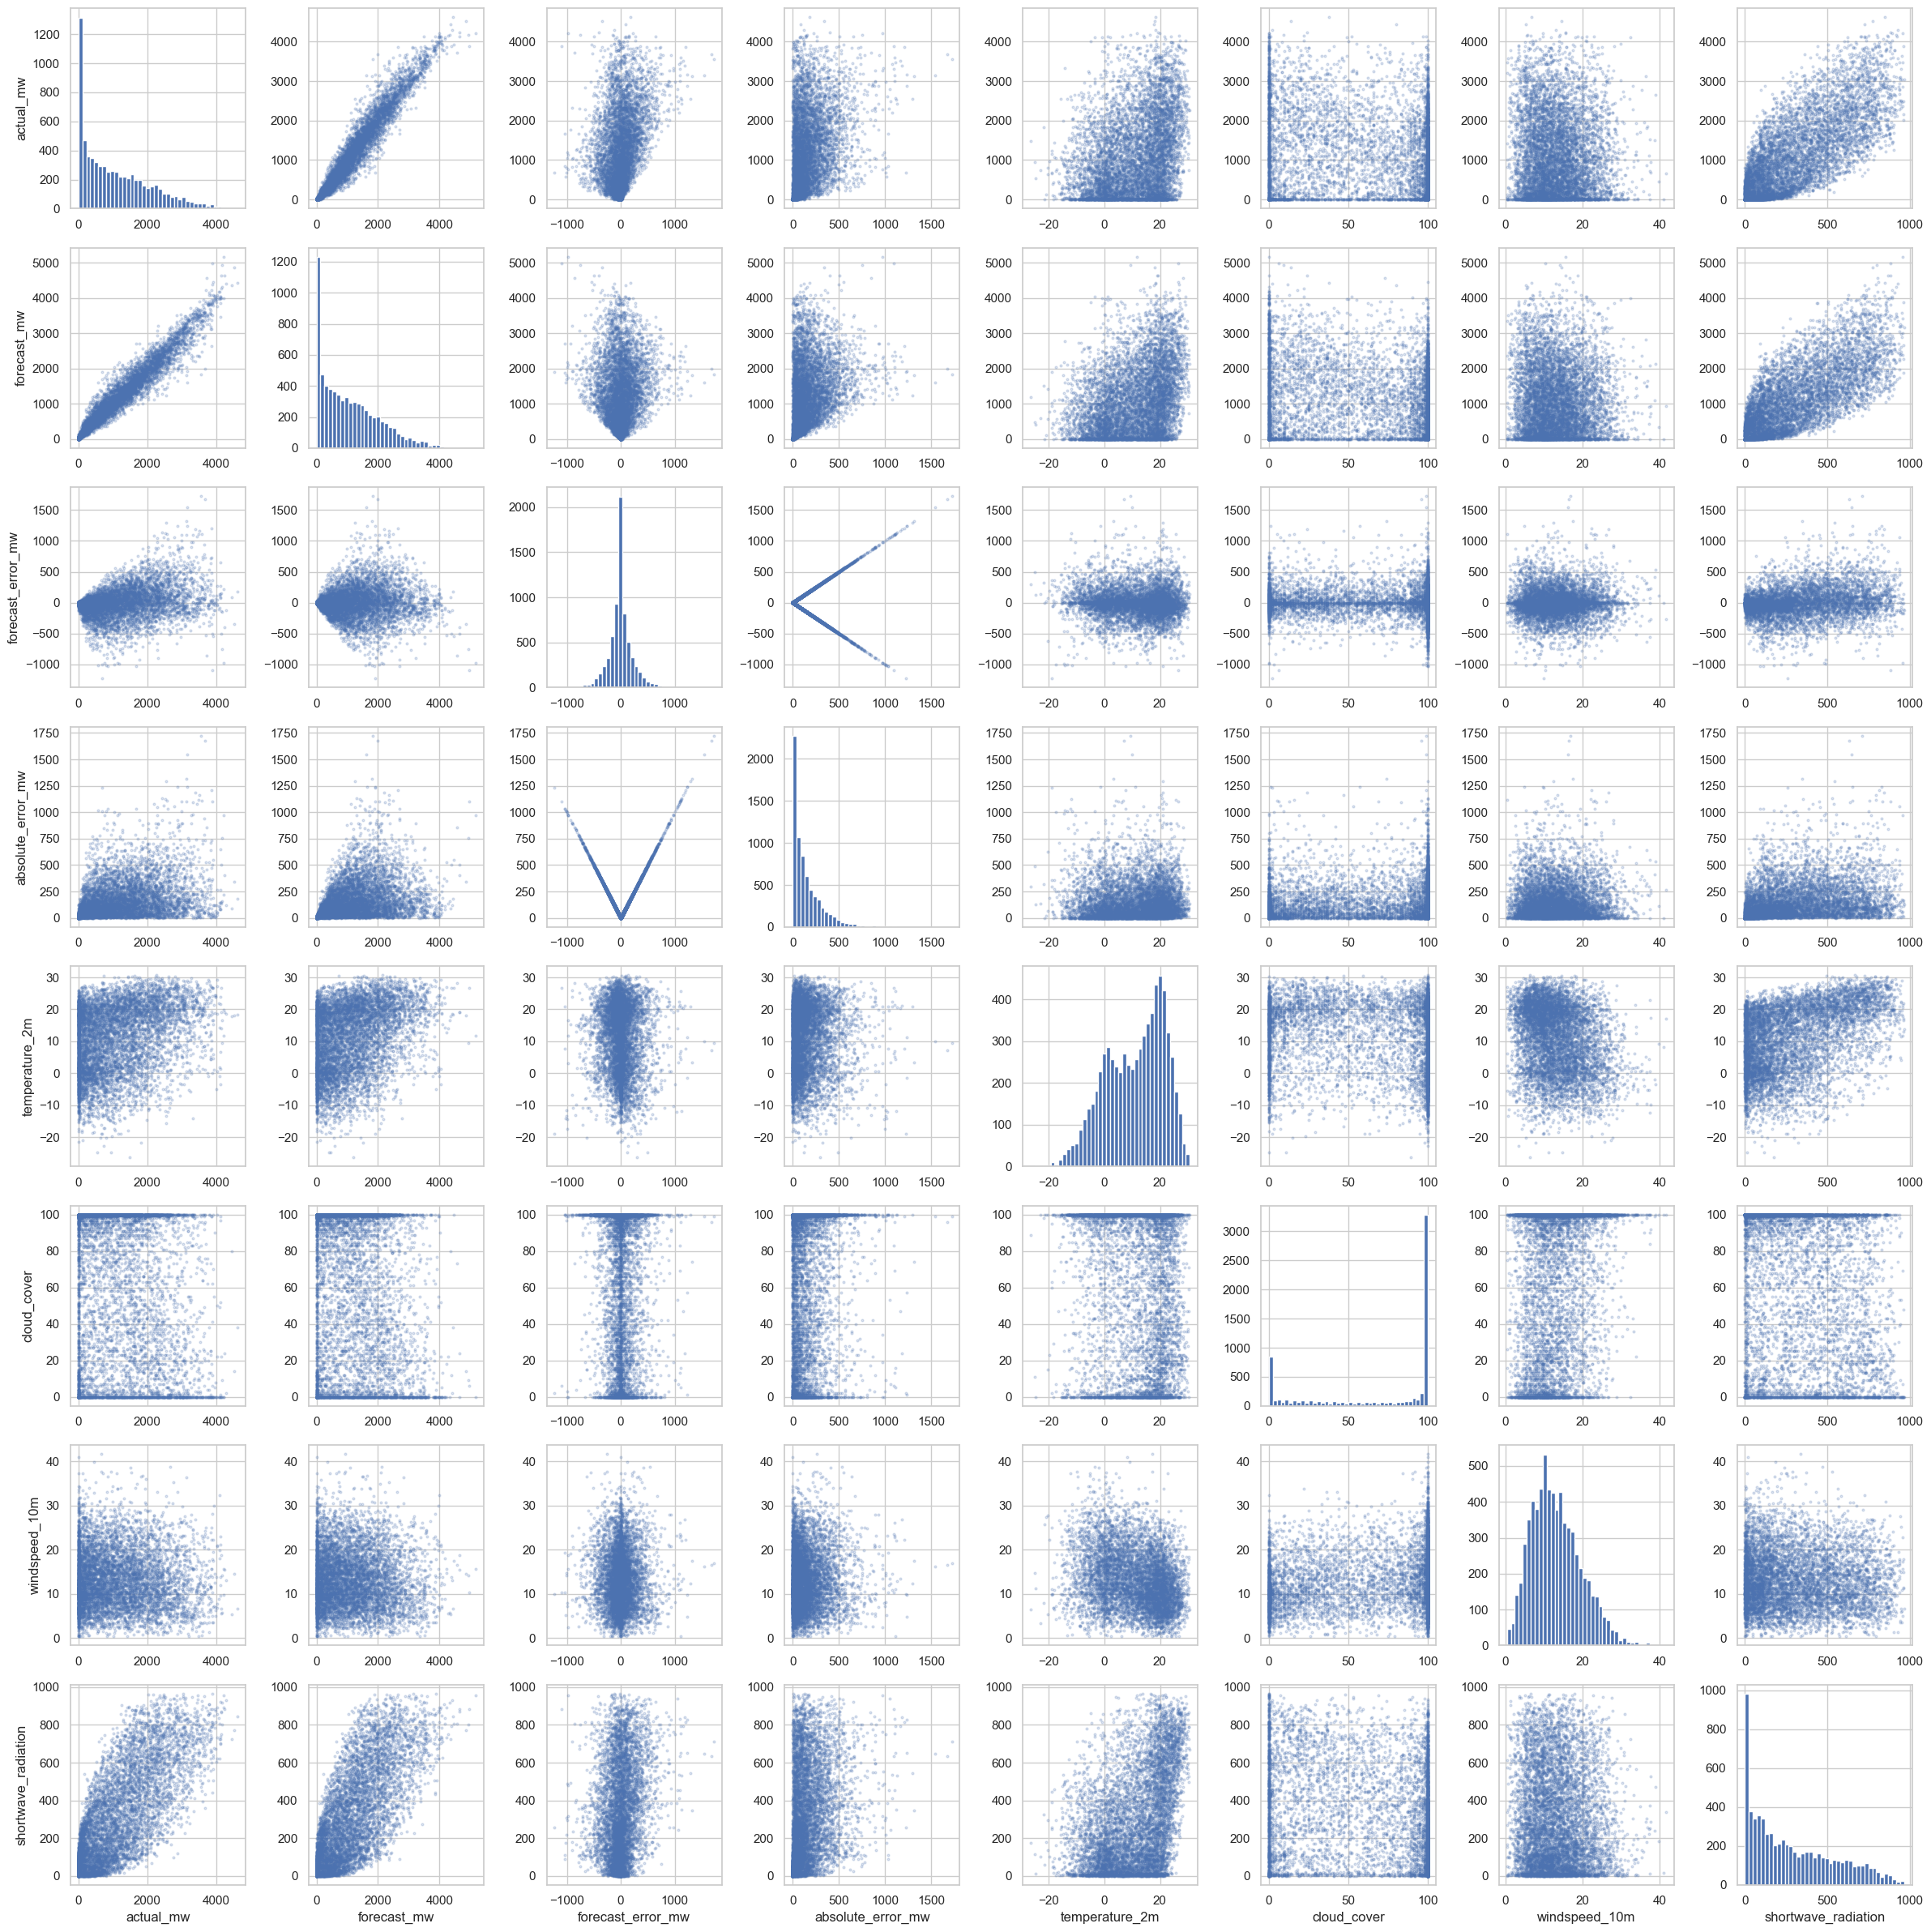

In [29]:
system_pair = system_daylight[
    [
        "actual_mw",
        "forecast_mw",
        "forecast_error_mw",
        "absolute_error_mw",
        "temperature_2m",
        "cloud_cover",
        "windspeed_10m",
        "shortwave_radiation",
    ]
].dropna().copy()

if len(system_pair) > 7000:
    system_pair = system_pair.sample(7000, random_state=42)

pair_cols = system_pair.columns.tolist()
n = len(pair_cols)

fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n))
for i, ycol in enumerate(pair_cols):
    for j, xcol in enumerate(pair_cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(system_pair[xcol], bins=40)
        else:
            ax.scatter(system_pair[xcol], system_pair[ycol], s=4, alpha=0.2)

        if i == n - 1:
            ax.set_xlabel(xcol)
        else:
            ax.set_xlabel("")

        if j == 0:
            ax.set_ylabel(ycol)
        else:
            ax.set_ylabel("")

plt.tight_layout()
plt.show()

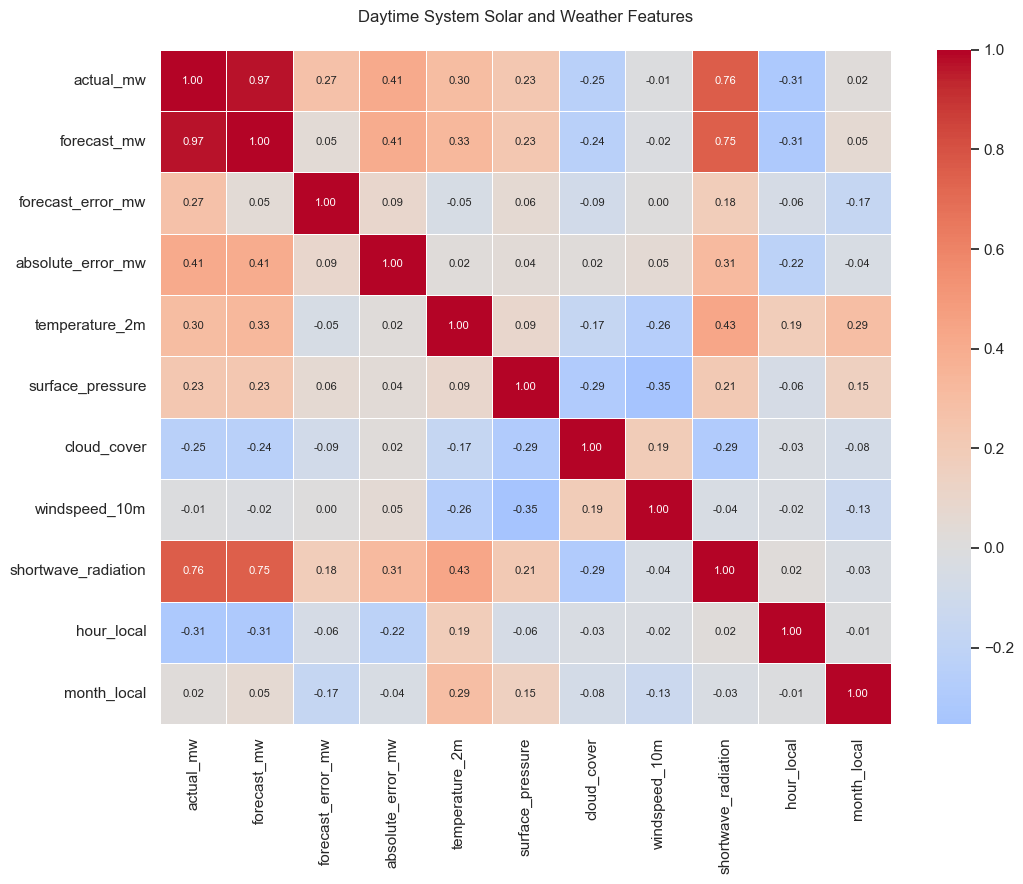

In [30]:
system_corr_cols = [
    "actual_mw",
    "forecast_mw",
    "forecast_error_mw",
    "absolute_error_mw",
    "temperature_2m",
    "surface_pressure",
    "cloud_cover",
    "windspeed_10m",
    "shortwave_radiation",
    "hour_local",
    "month_local",
]
system_daylight_corr = system_daylight[system_corr_cols].corr(numeric_only=True)


plt.figure(figsize=(11, 9))
sns.heatmap( 
    system_daylight_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8},
)
plt.title("Daytime System Solar and Weather Features", pad=20)
plt.tight_layout()
plt.show()

## Findings for Modeling

## Conclusion and Next Steps
The next step is